**Pràctica: Visualització i Anàlisi de Dades**

Cristina Galter
Juny 2025

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite

# Carreguem dades
edges = []
with open("out.moreno_crime_crime") as f:
    for line in f:
        if not line.startswith('%'):
            u, v = map(int, line.strip().split())
            edges.append((u, v + 829))  # desplacem els crims per separar-los de persones

# Graf bipartit
B = nx.Graph()
B.add_edges_from(edges)

# Assignem tipus bipartits
for node in B.nodes():
    B.nodes[node]['bipartite'] = 'person' if node <= 829 else 'crime'

# Llegim noms, sexes i rols
with open("ent.moreno_crime_crime.person.name") as f:
    names = [line.strip() for line in f]
with open("ent.moreno_crime_crime.person.sex") as f:
    sexes = [int(line.strip()) for line in f]
with open("rel.moreno_crime_crime.person.role") as f:
    roles = [line.strip() for line in f]

# Afegim atributs als nodes persona
for i in range(len(names)):
    node_id = i + 1
    if node_id in B:
        B.nodes[node_id]["name"] = names[i]
        B.nodes[node_id]["sex"] = "Home" if sexes[i] == 1 else "Dona"
        B.nodes[node_id]["role"] = roles[i] if i < len(roles) else "Desconegut"

# Graf només entre persones (co-implicació en crims)

persons = [n for n, d in B.nodes(data=True) if d['bipartite'] == 'person']
G = bipartite.weighted_projected_graph(B, persons)

<ipython-input-37-dbb1f86f3fdc>:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


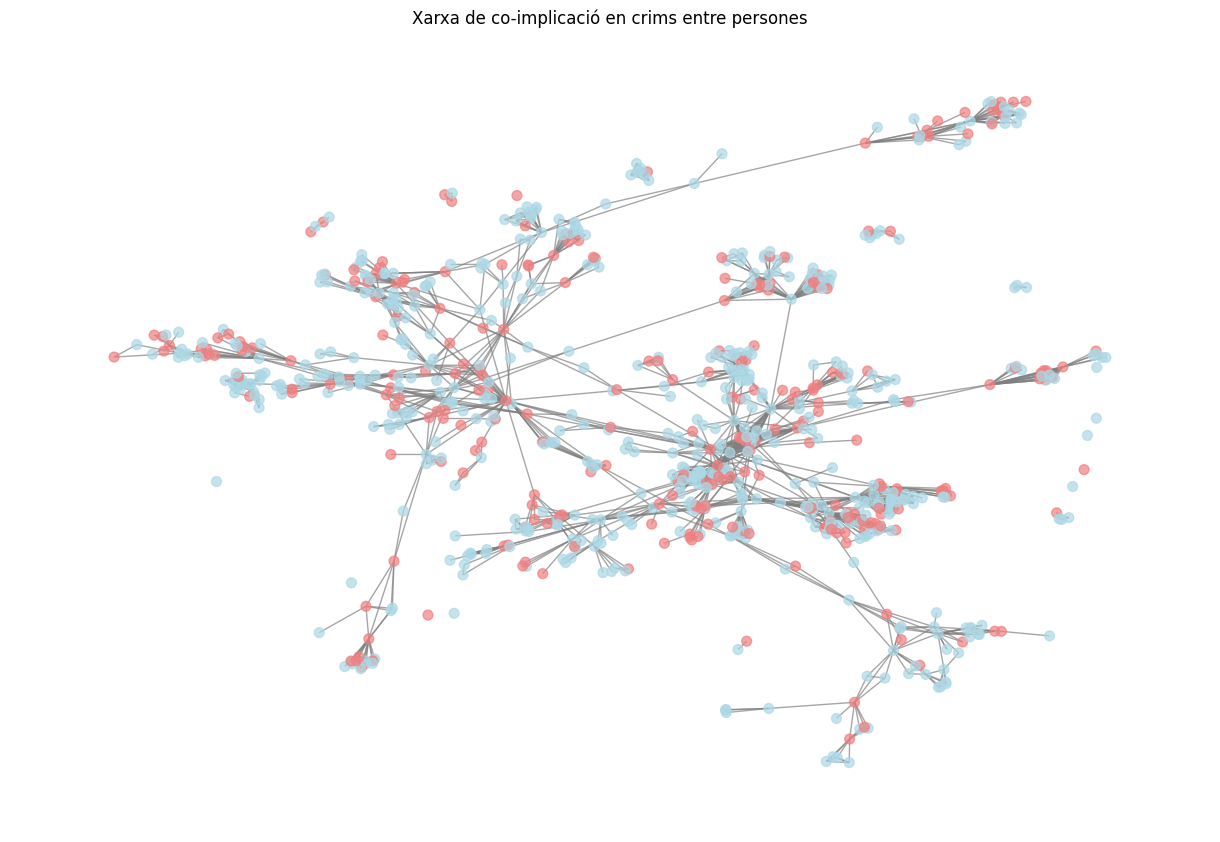

In [ ]:
# Creem una visualització del graf que mostri els colors segons el sexe
colors = []
for node in G.nodes():
    sex = B.nodes[node].get("sex", "Desconegut")
    if sex == "Home":
        colors.append("lightblue")
    elif sex == "Dona":
        colors.append("lightcoral")
    else:
        colors.append("gray")

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos,
        node_color=colors,
        with_labels=False,
        node_size=50,
        edge_color='gray',
        alpha=0.7)
plt.title("Xarxa de co-implicació en crims entre persones")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
for node in G.nodes():
    info = B.nodes[node]
    G.nodes[node]["label"] = info.get("name", f"Persona {node}")
    G.nodes[node]["sex"] = info.get("sex", "Desconegut")
    G.nodes[node]["role"] = info.get("role", "Desconegut")
    G.nodes[node]["degree"] = G.degree[node]  # Mida proporcional
    G.nodes[node]["weight"] = sum([d["weight"] for _, _, d in G.edges(node, data=True)])  # Pes total de connexions

    # Color segons sexe
    if info.get("sex") == "Home":
        G.nodes[node]["viz"] = {"color": {"r": 80, "g": 150, "b": 255}}
    elif info.get("sex") == "Dona":
        G.nodes[node]["viz"] = {"color": {"r": 255, "g": 100, "b": 150}}
    else:
        G.nodes[node]["viz"] = {"color": {"r": 200, "g": 200, "b": 200}}

for u, v, d in G.edges(data=True):
    d["weight"] = d.get("weight", 1)

# Exportem a .gexf amb tots els atributs
nx.write_gexf(G, "xarxa_criminals_gephi.gexf")
print("Graf exportat com xarxa_criminals_gephi.gexf per Gephi.")

Graf exportat com xarxa_criminals_gephi.gexf per Gephi.


In [ ]:
degree = dict(G.degree())
eigen = nx.eigenvector_centrality(G, max_iter=1000)
betweenness = nx.betweenness_centrality(G)

# Top 5 persones per cada mètrica
def top(dic, label):
    print(f"\n{label}")
    for node, val in sorted(dic.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"{B.nodes[node]['name']} ({B.nodes[node]['role']}): {val:.4f}")

top(degree, "Grau")
top(eigen, "Centralitat de vector propi")
top(betweenness, "Centralitat de betweenness")


Grau
KatzLuella (Suspect): 51.0000
AbramsChad (Victim): 48.0000
HemphillBud (Victim): 44.0000
BendixJerryLee (Suspect): 33.0000
SmithMichaelThomas (Suspect): 33.0000

Centralitat de vector propi
KatzLuella (Suspect): 0.3077
SmithMichaelThomas (Suspect): 0.2608
SteinerCatherine (Suspect): 0.2254
BendixJerryLee (Suspect): 0.2149
BinderErrol (Suspect): 0.2089

Centralitat de betweenness
WillisJenny (Witness): 0.3496
SlatteryMaurice (Suspect): 0.2505
AbramsChad (Victim): 0.1869
BendixJerryLee (Suspect): 0.1569
SteinerCatherine (Suspect): 0.1542


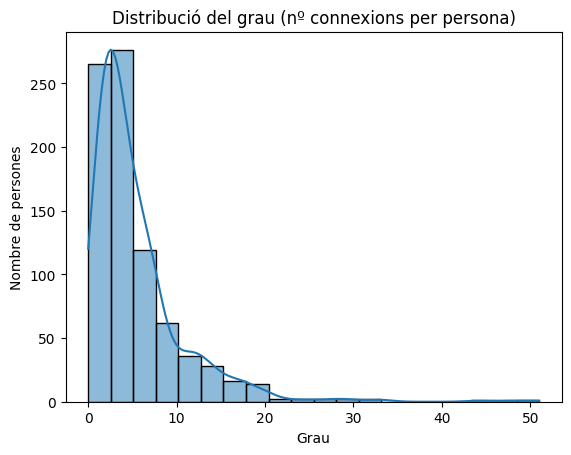

In [ ]:
import seaborn as sns
import pandas as pd

graus = [G.degree(n) for n in G.nodes()]
sns.histplot(graus, bins=20, kde=True)
plt.title("Distribució del grau (nº connexions per persona)")
plt.xlabel("Grau")
plt.ylabel("Nombre de persones")
plt.show()


In [ ]:
print("Connectivitat:")
print("És connex?", nx.is_connected(G))
print("Nombre de components:", nx.number_connected_components(G))

largest_cc = max(nx.connected_components(G), key=len)
print("Mida del component principal:", len(largest_cc))

Connectivitat:
És connex? False
Nombre de components: 20
Mida del component principal: 754


In [ ]:
import community as community_louvain

partition = community_louvain.best_partition(G)
num_communities = len(set(partition.values()))
print(f"Comunitats detectades: {num_communities}")

# Exemples per comunitat
from collections import defaultdict

comunitats = defaultdict(list)
for node, com in partition.items():
    comunitats[com].append(B.nodes[node]["name"])

for com_id, membres in list(comunitats.items())[:3]:
    print(f"\nComunitat {com_id} ({len(membres)} membres):")
    print(", ".join(membres[:5]) + "...")

Comunitats detectades: 47

Comunitat 5 (49 membres):
AbelDennis, AdamsReggie, AndersonMitch, ArcherThora, Archer Jr.Dylan...

Comunitat 1 (79 membres):
AbramsChad, AbramsDon, AbramsRichard, AveryTerry, BarkerCatherine...

Comunitat 28 (57 membres):
AbramsDavid, BergDon, BobbseyPenelope, BolandLaura, BrowningCalder...


In [ ]:
print("Interaccions rellevants (més de 3 crims junts):")
for u, v, d in G.edges(data=True):
    if d['weight'] > 3:
        print(f"{B.nodes[u]['name']} ↔ {B.nodes[v]['name']} → {d['weight']} crims compartits")

Interaccions rellevants (més de 3 crims junts):
AbramsChad ↔ BerkleyCallie → 4 crims compartits
AndersonMitch ↔ McCannEddie → 4 crims compartits
BlackRuth ↔ TroutBernard → 5 crims compartits
BosticDan ↔ SamuelLyle → 4 crims compartits
CantwellFelecia ↔ MitchellGrant → 5 crims compartits
JohnstonJustin ↔ KatzLuella → 4 crims compartits
KatzLuella ↔ SteinerCatherine → 5 crims compartits
MobleyLyle ↔ ParkerByron → 4 crims compartits


In [ ]:
# Proporció d'homes vs dones
homes = sum(1 for n in persons if B.nodes[n]['sex'] == 'Home')
dones = sum(1 for n in persons if B.nodes[n]['sex'] == 'Dona')
print(f"Sexe: {homes} Homes, {dones} Dones")

# Rols més comuns
from collections import Counter
rols = Counter(B.nodes[n]['role'] for n in persons)
print("\nRols:")
for r, count in rols.most_common():
    print(f"{r}: {count} persones")

# Detecció de comunitats formades exclusivament per víctimes o sospitosos
for com_id, membres in comunitats.items():
    rols_com = set(B.nodes[names.index(name)+1]['role'] for name in membres)
    if len(rols_com) == 1:
        print(f"\nComunitat {com_id} amb únic rol: {list(rols_com)[0]}")

Sexe: 558 Homes, 271 Dones

Rols:
Suspect: 373 persones
Victim: 317 persones
Witness: 117 persones
Victim Suspect: 22 persones

Comunitat 37 amb únic rol: Victim

Comunitat 39 amb únic rol: Suspect

Comunitat 44 amb únic rol: Victim

Comunitat 40 amb únic rol: Suspect

Comunitat 9 amb únic rol: Witness

Comunitat 19 amb únic rol: Suspect

Comunitat 22 amb únic rol: Suspect

Comunitat 23 amb únic rol: Victim

Comunitat 27 amb únic rol: Suspect

Comunitat 31 amb únic rol: Suspect


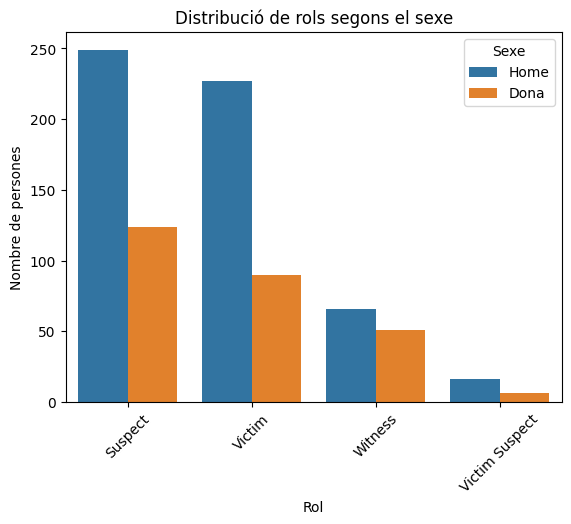

In [ ]:
df = pd.DataFrame({
    "Sexe": [B.nodes[n]['sex'] for n in persons],
    "Rol": [B.nodes[n]['role'] for n in persons]
})

sns.countplot(data=df, x="Rol", hue="Sexe")
plt.title("Distribució de rols segons el sexe")
plt.xlabel("Rol")
plt.ylabel("Nombre de persones")
plt.xticks(rotation=45)
plt.show()

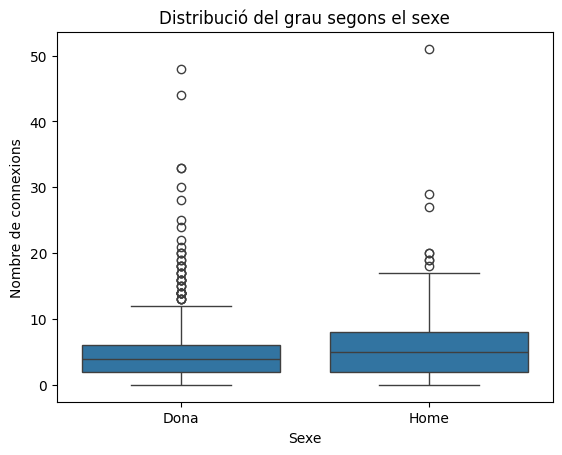

In [ ]:
df_sex_degree = pd.DataFrame({
    "Sexe": [B.nodes[n]['sex'] for n in persons],
    "Grau": [G.degree(n) for n in persons]
})

sns.boxplot(data=df_sex_degree, x="Sexe", y="Grau")
plt.title("Distribució del grau segons el sexe")
plt.ylabel("Nombre de connexions")
plt.xticks(ticks=[0,1], labels=["Dona", "Home"])
plt.show()

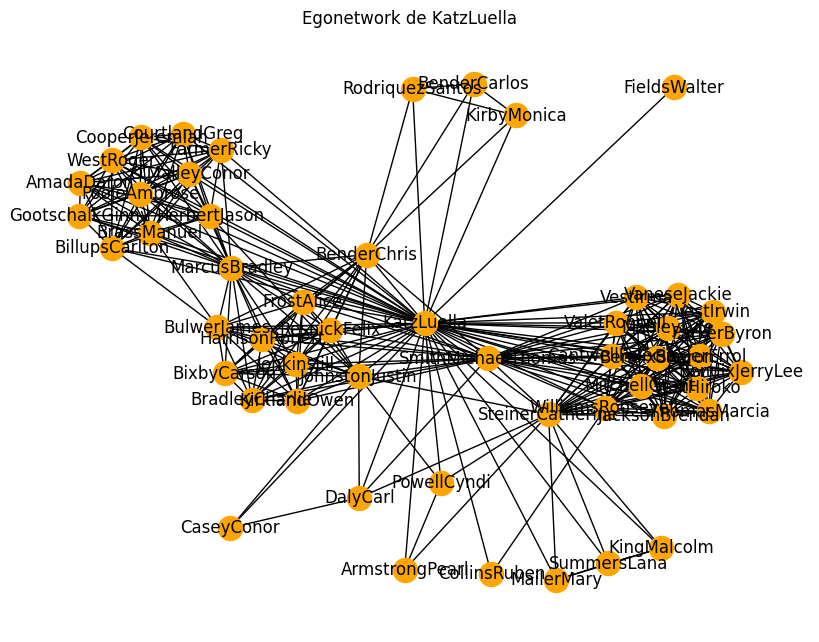

In [ ]:
# Trobem la persona amb més centralitat
top_person = max(eigen, key=eigen.get)
ego = nx.ego_graph(G, top_person)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(ego)
nx.draw(ego, pos, with_labels=True,
        labels={n: B.nodes[n]["name"] for n in ego.nodes()},
        node_size=300, node_color="orange")
plt.title(f"Egonetwork de {B.nodes[top_person]['name']}")
plt.show()

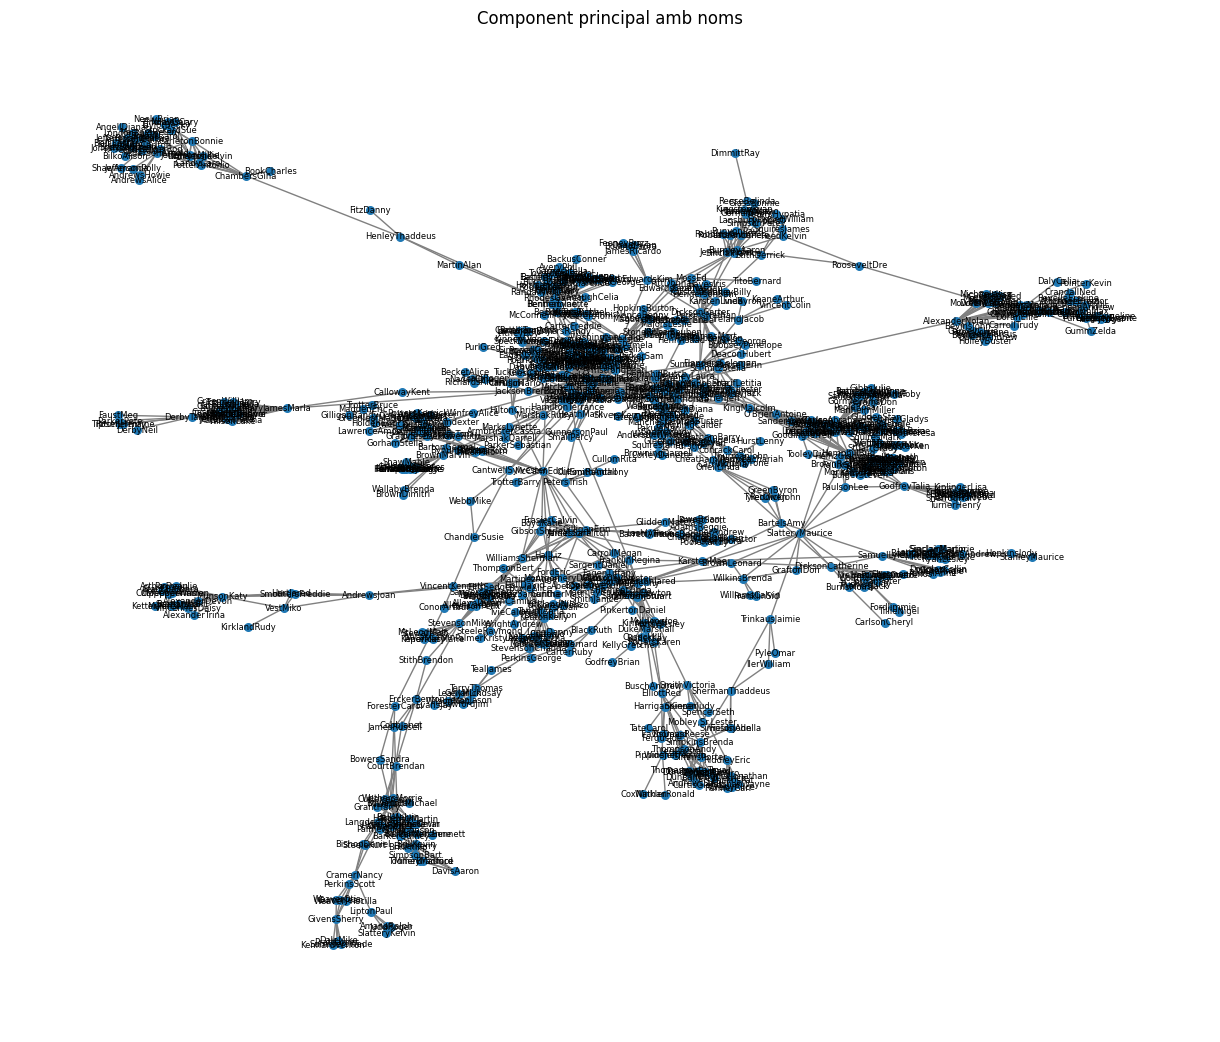

In [ ]:
subG = G.subgraph(largest_cc)
pos = nx.spring_layout(subG, seed=42)

plt.figure(figsize=(12, 10))
nx.draw(subG, pos, with_labels=False, node_size=30, edge_color='gray')
nx.draw_networkx_labels(subG, pos, labels={n: B.nodes[n]['name'] for n in subG.nodes}, font_size=6)
plt.title("Component principal amb noms")
plt.show()

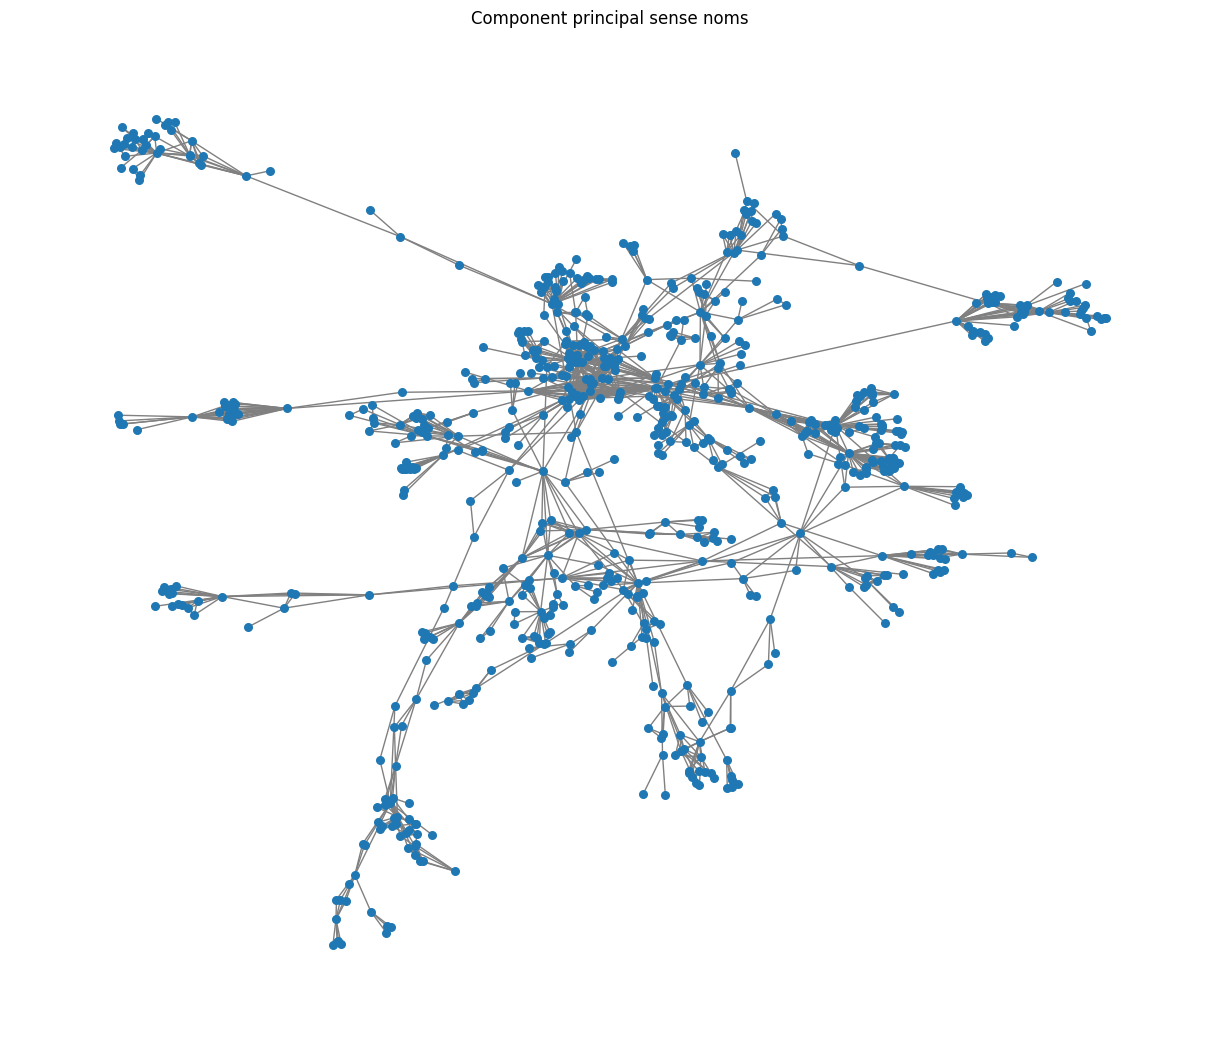

In [ ]:
subG = G.subgraph(largest_cc)
pos = nx.spring_layout(subG, seed=42)

plt.figure(figsize=(12, 10))
nx.draw(subG, pos, with_labels=False, node_size=30, edge_color='gray')
plt.title("Component principal sense noms")
plt.show()

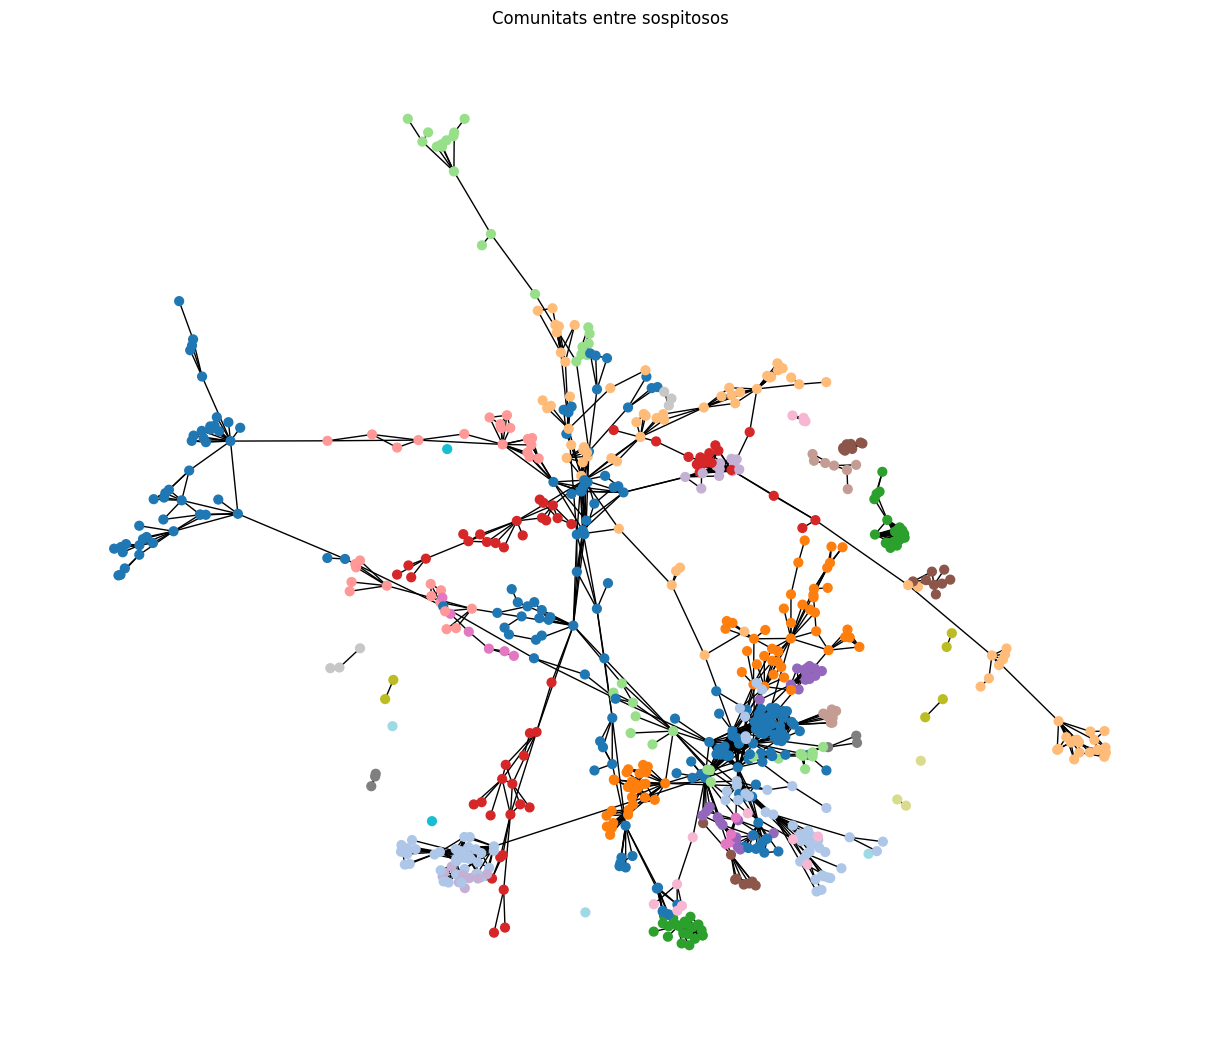

In [ ]:
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G_suspects))
color_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        color_map[node] = i

colors = [color_map.get(n, 0) for n in G_suspects.nodes()]

plt.figure(figsize=(12, 10))
nx.draw_spring(G_suspects, node_color=colors, node_size=40, with_labels=False, cmap=plt.cm.tab20)
plt.title("Comunitats entre sospitosos")
plt.show()